# 6CS012 – Part III: Natural Language Processing Task
## Hate Speech Detection: Binary Tweet Classification using RNN, LSTM & Word2Vec

**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Dataset:** Racist / Sexist Tweets  
**Objective:** Binary Text Classification — Label `1` = Hate Speech &nbsp;|&nbsp; Label `0` = Neutral  


## Section 1: Environment Setup


### 1.1 Dependency Installation


In [ ]:
# One-time install of all required packages for this notebook
!pip install numpy==1.23.5 gensim nltk wordcloud gradio -q

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### 1.2 Module Imports


In [ ]:
# Built-in modules
import re
import time
import warnings
warnings.filterwarnings('ignore')

# Numerical and tabular data
import numpy as np
import pandas as pd

# Plotting and visual analytics
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural language processing toolkit
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras / TensorFlow components
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Pre-trained vector loading via Gensim
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])
import gensim.downloader as gensim_api

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")

TensorFlow: 2.20.0 | NumPy: 2.0.2


### 1.3 Drive Mount (Colab)


In [ ]:
# Connect Google Drive to access the dataset files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2: Data Ingestion


### 2.1 Dataset File Paths


In [ ]:
TRAIN_PATH = '/content/drive/MyDrive/Sem6/AI/Assignment/NLP-Model/train_racisit.csv'
TEST_PATH  = '/content/drive/MyDrive/Sem6/AI/Assignment/NLP-Model/test_racisit.csv'

### 2.2 Read CSV Files into DataFrames


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

### 2.3 Initial Data Preview


In [ ]:
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")
train_df.head()

Train shape: (31962, 3) | Test shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
test_df.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


## Section 3: Exploratory Analysis


### 3.1 Schema & Null Check


In [ ]:
# Inspect column types and count any null entries
train_df.info()
print("\nMissing values:\n", train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB

Missing values:
 id       0
label    0
tweet    0
dtype: int64


### 3.2 Label Balance


In [ ]:
# Count label occurrences and compute class proportions
label_counts = train_df['label'].value_counts()
print(f"Class 0 (Not Hate): {label_counts[0]} ({label_counts[0]/len(train_df)*100:.1f}%)")
print(f"Class 1 (Hate)    : {label_counts[1]} ({label_counts[1]/len(train_df)*100:.1f}%)")

Class 0 (Not Hate): 29720 (93.0%)
Class 1 (Hate)    : 2242 (7.0%)


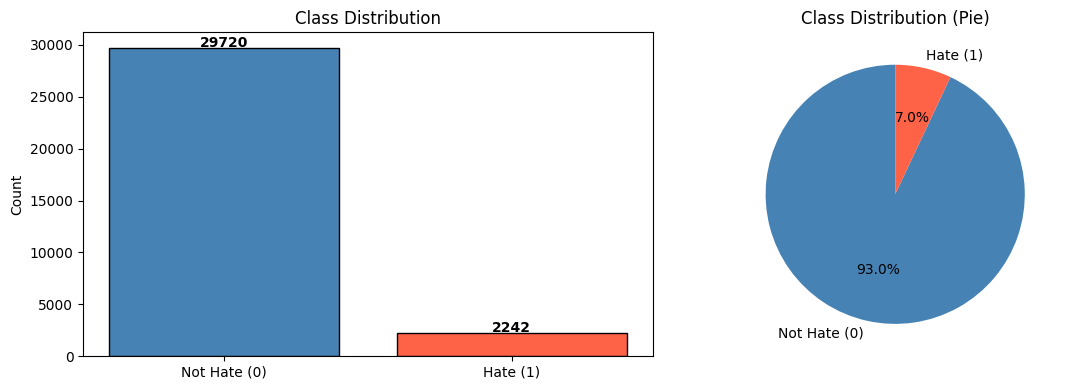

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Hate (0)', 'Hate (1)'], label_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=['Not Hate (0)', 'Hate (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (Pie)')
plt.tight_layout()
plt.show()

### 3.3 Token Count Distribution


In [ ]:
# Compute word count per tweet and summarise by class
train_df['tweet_length'] = train_df['tweet'].apply(lambda x: len(str(x).split()))
print(train_df['tweet_length'].describe())

count    31962.00000
mean        13.15872
std          5.47815
min          3.00000
25%          9.00000
50%         13.00000
75%         17.00000
max         34.00000
Name: tweet_length, dtype: float64


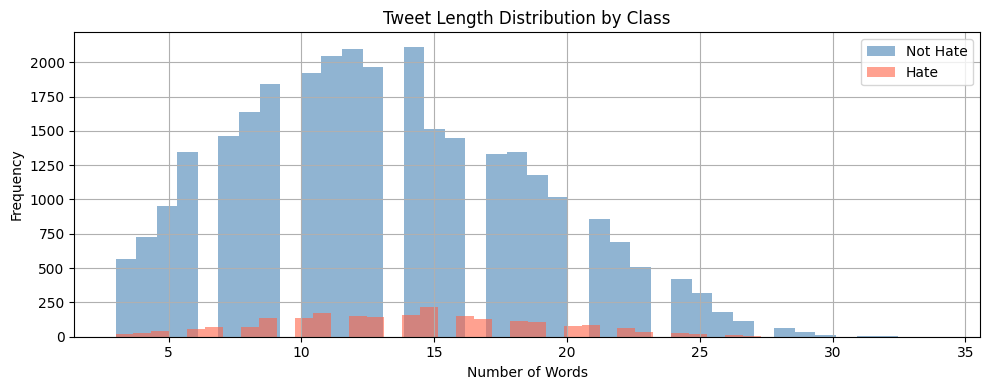

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
train_df[train_df['label'] == 0]['tweet_length'].hist(bins=40, alpha=0.6, color='steelblue', label='Not Hate', ax=ax)
train_df[train_df['label'] == 1]['tweet_length'].hist(bins=40, alpha=0.6, color='tomato', label='Hate', ax=ax)
ax.set_title('Tweet Length Distribution by Class')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Raw Tweet Samples


In [ ]:
# Print a few raw examples from both label categories
print("Non-Hate samples:")
for t in train_df[train_df['label'] == 0]['tweet'].head(3).values:
    print(" •", t)

print("\nHate samples:")
for t in train_df[train_df['label'] == 1]['tweet'].head(3).values:
    print(" •", t)

Non-Hate samples:
 •  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
 • @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
 •   bihday your majesty

Hate samples:
 • @user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
 • no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphins
 • retweet if you agree! 


## Section 4: Text Cleaning


### 4.1 Cleaning Configuration


In [ ]:
# Lookup table for expanding common English contractions
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "didn't": "did not", "doesn't": "does not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "what's": "what is",
    "he's": "he is", "she's": "she is", "they're": "they are",
    "you're": "you are", "we're": "we are", "you've": "you have",
    "they've": "they have", "you'll": "you will", "they'll": "they will",
    "let's": "let us", "there's": "there is",
}

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

### 4.2 Contraction Resolver


In [ ]:
def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

### 4.3 Text Normalisation Pipeline


In [ ]:
# Sequential cleaning: lowercase, strip URLs/mentions/hashtags, expand contractions, remove non-alpha, filter stopwords, lemmatize
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@[\w]+', '', text)
    text = re.sub(r'#', '', text)
    text = expand_contractions(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

### 4.4 Run Cleaning


In [ ]:
# Run the normalisation pipeline over every tweet in both splits
train_df['clean_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['clean_tweet']  = test_df['tweet'].apply(clean_tweet)

### 4.5 Before / After Comparison


In [ ]:
print("Before → After (3 examples):")
for i in range(3):
    print(f"\n  ORIGINAL : {train_df['tweet'].iloc[i]}")
    print(f"  CLEANED  : {train_df['clean_tweet'].iloc[i]}")

Before → After (3 examples):

  ORIGINAL :  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
  CLEANED  : father dysfunctional selfish drag kid dysfunction run

  ORIGINAL : @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  CLEANED  : thanks lyft credit use cause offer wheelchair van pdx disapointed getthanked

  ORIGINAL :   bihday your majesty
  CLEANED  : bihday majesty


### 4.6 Term Frequency Word Clouds


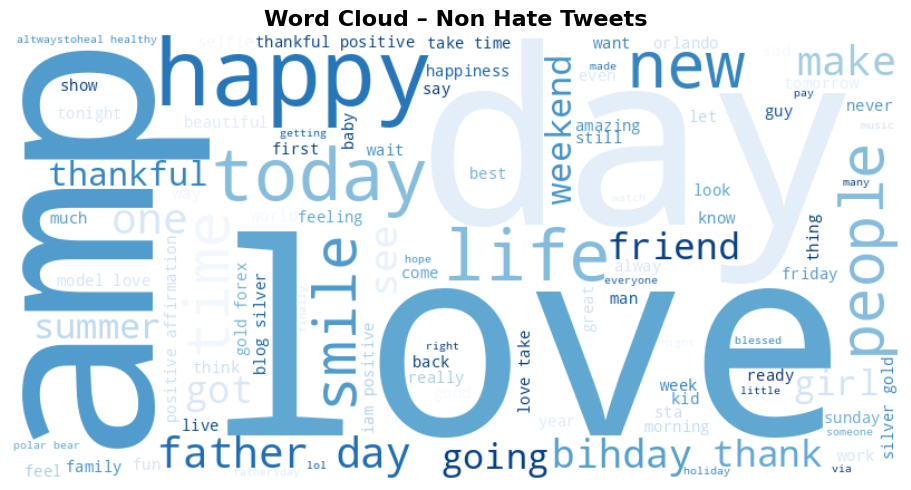

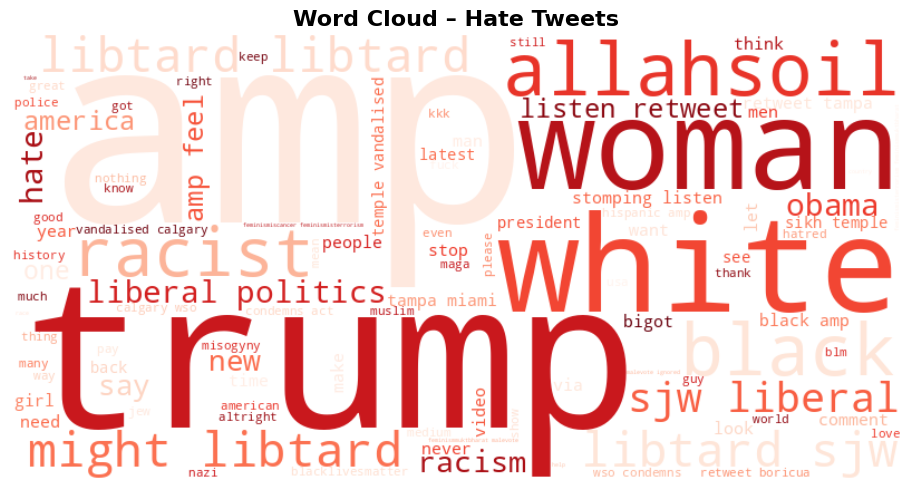

In [ ]:
# Generate term-frequency word clouds for each label category
def make_wordcloud(texts, title, colormap='Blues'):
    corpus = ' '.join(texts)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=colormap, max_words=100).generate(corpus)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

make_wordcloud(train_df[train_df['label'] == 0]['clean_tweet'].values, 'Word Cloud – Non Hate Tweets', 'Blues')
make_wordcloud(train_df[train_df['label'] == 1]['clean_tweet'].values, 'Word Cloud – Hate Tweets', 'Reds')

## Section 5: Sequence Encoding


### 5.1 Global Settings


In [ ]:
# Shared hyperparameters used across all three models
VOCAB_SIZE    = 10_000
OOV_TOKEN     = '<OOV>'
EMBEDDING_DIM = 50
BATCH_SIZE    = 64
EPOCHS        = 20

### 5.2 Stratified Train / Validation Split


In [ ]:
# Separate features and labels before splitting
X = train_df['clean_tweet'].values
y = train_df['label'].values

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 25569 | Val: 6393


### 5.3 Vocabulary Fitting


In [ ]:
# Build word-to-index vocabulary from training corpus only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)
print(f"Full vocab: {len(tokenizer.word_index)} | Capped at: {VOCAB_SIZE}")

Full vocab: 31856 | Capped at: 10000


### 5.4 Max Sequence Length Selection


In [ ]:
# 95th-percentile length keeps most tweets whole while limiting padding waste
MAX_LEN = int(np.percentile([len(s.split()) for s in X_train], 95))
print(f"MAX_LEN (95th percentile): {MAX_LEN}")

MAX_LEN (95th percentile): 12


### 5.5 Integer Encoding & Padding


In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_tweet'].values)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad: {X_train_pad.shape} | X_val_pad: {X_val_pad.shape}")

X_train_pad: (25569, 12) | X_val_pad: (6393, 12)


### 5.6 Shared Utility Functions


In [ ]:
# Utility: render side-by-side accuracy and loss learning curves
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric], label=f'Train {metric.capitalize()}')
        ax.plot(history.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
        ax.set_title(f'{model_name} – {metric.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Utility: threshold predictions, report per-class metrics, and display confusion matrix
def evaluate_model(model, X_val_pad, y_val, model_name):
    y_pred = (model.predict(X_val_pad, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_val, y_pred)
    print(f"\n{model_name} | Accuracy: {acc*100:.2f}%")
    print(classification_report(y_val, y_pred, target_names=['Not Hate', 'Hate']))
    ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred),
                           display_labels=['Not Hate', 'Hate']).plot(cmap='Blues')
    plt.title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return acc, y_pred


In [ ]:
# Utility: returns early-stopping and best-checkpoint callbacks for any model
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{name}_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

## Section 6: Baseline — Simple RNN


### 6.1 Network Architecture


In [ ]:
# Simple RNN baseline: learned embeddings feed into a single recurrent layer
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model1_SimpleRNN')

model1.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

### 6.2 Architecture Summary


In [ ]:
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.3 Training & Results


Epoch 1/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9315 - loss: 0.2576

400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9455 - loss: 0.1893 - val_accuracy: 0.9512 - val_loss: 0.1368
Epoch 2/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9755 - loss: 0.0762

400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9752 - loss: 0.0782 - val_accuracy: 0.9598 - val_loss: 0.1259
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9877 - loss: 0.0399 - val_accuracy: 0.9585 - val_loss: 0.1717
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9553 - val_loss: 0.1785
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9945 - loss: 0.0185 - val_accuracy: 0.9537 - val_loss: 0.1818
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9969 - loss: 0.0106 - val_accuracy: 0.9390 - val_loss: 0.2573
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
Training time: 0.7 min


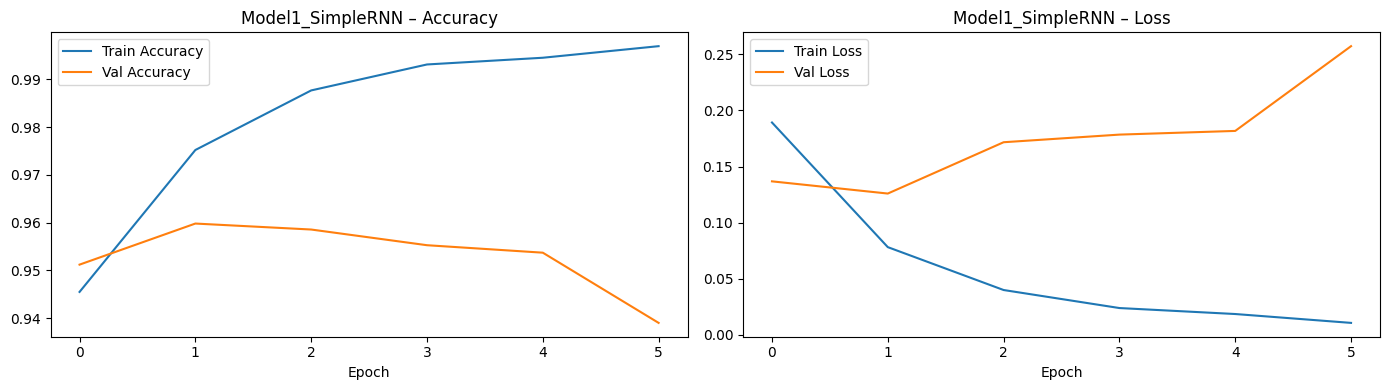


Model1_SimpleRNN | Accuracy: 95.98%
              precision    recall  f1-score   support

    Not Hate       0.97      0.99      0.98      5945
        Hate       0.78      0.59      0.67       448

    accuracy                           0.96      6393
   macro avg       0.88      0.79      0.83      6393
weighted avg       0.96      0.96      0.96      6393



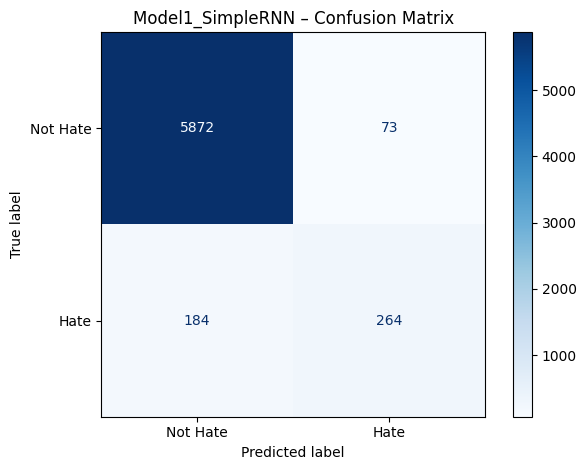

In [ ]:
# Fit the Simple RNN and record training time
t0 = time.time()
history1 = model1.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=get_callbacks('model1'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

plot_history(history1, 'Model1_SimpleRNN')
acc1, pred1 = evaluate_model(model1, X_val_pad, y_val, 'Model1_SimpleRNN')

## Section 7: LSTM with Learned Embeddings


### 7.1 Network Architecture


In [ ]:
# LSTM variant: replaces the vanilla RNN cell with gated LSTM units
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model2_LSTM')

model2.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])


### 7.2 Architecture Summary


In [ ]:
model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.3 Training


In [ ]:
# Fit the LSTM model and record training time
t0 = time.time()
history2 = model2.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=get_callbacks('model2'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9287 - loss: 0.2792

400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9457 - loss: 0.1895 - val_accuracy: 0.9607 - val_loss: 0.1247
Epoch 2/20
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9743 - loss: 0.0794

400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9738 - loss: 0.0824 - val_accuracy: 0.9629 - val_loss: 0.1183
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9837 - loss: 0.0539 - val_accuracy: 0.9615 - val_loss: 0.1326
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9881 - loss: 0.0409 - val_accuracy: 0.9606 - val_loss: 0.1705
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9909 - loss: 0.0316 - val_accuracy: 0.9585 - val_loss: 0.1868
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9922 - loss: 0.0256 - val_accuracy: 0.9617 - val_loss: 0.2180
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
Training time: 1.0 min


### 7.4 Results


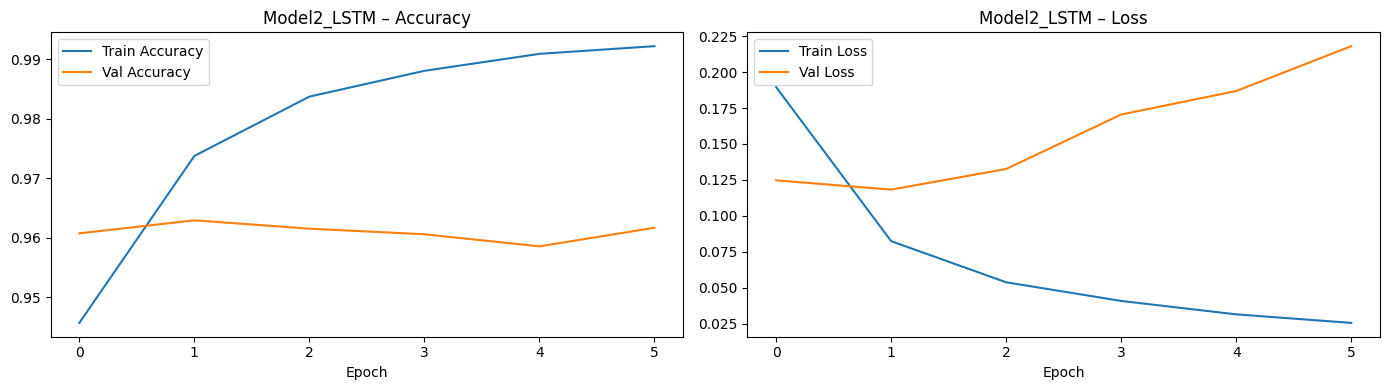


Model2_LSTM | Accuracy: 96.29%
              precision    recall  f1-score   support

    Not Hate       0.97      0.99      0.98      5945
        Hate       0.79      0.64      0.71       448

    accuracy                           0.96      6393
   macro avg       0.88      0.81      0.84      6393
weighted avg       0.96      0.96      0.96      6393



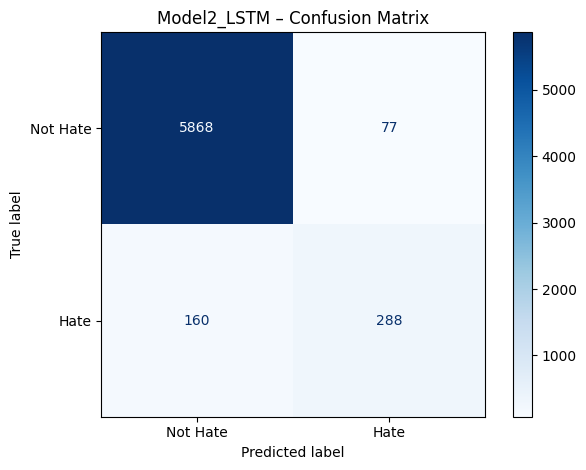

In [ ]:

plot_history(history2, 'Model2_LSTM')
acc2, pred2 = evaluate_model(model2, X_val_pad, y_val, 'Model2_LSTM')

## Section 8: LSTM with Pre-trained Word2Vec


### 8.1 Load Word2Vec Vectors


In [ ]:
# Fetch Google News Word2Vec (300-dim, ~1.6 GB) — run once and cache locally
w2v_model = gensim_api.load('word2vec-google-news-300')
EMBEDDING_DIM_W2V = 300   # must match the loaded model's vector size
print("Word2Vec loaded.")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded.


### 8.2 Construct Embedding Matrix


In [ ]:
# Populate the embedding matrix with Word2Vec vectors for known vocabulary words
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))
found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        found += 1

In [ ]:
print(f"Words mapped to Word2Vec: {found} | Coverage: {found/min(VOCAB_SIZE, len(tokenizer.word_index))*100:.1f}%")

Words mapped to Word2Vec: 7601 | Coverage: 76.0%


### 8.3 Network Architecture


In [ ]:
# LSTM + Word2Vec: pre-trained vectors are frozen so only downstream layers learn
model3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM_W2V,
              weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model3_LSTM_Word2Vec')

model3.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

### 8.4 Training


In [ ]:
# Fit the Word2Vec-backed LSTM and record training time
t0 = time.time()
history3 = model3.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=get_callbacks('model3'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9249 - loss: 0.2689

400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9404 - loss: 0.1922 - val_accuracy: 0.9465 - val_loss: 0.1468
Epoch 2/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9504 - loss: 0.1433

400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9497 - loss: 0.1446 - val_accuracy: 0.9495 - val_loss: 0.1415
Epoch 3/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9550 - loss: 0.1290

400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9537 - loss: 0.1322 - val_accuracy: 0.9509 - val_loss: 0.1376
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9579 - loss: 0.1207

400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9569 - loss: 0.1230 - val_accuracy: 0.9559 - val_loss: 0.1315
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9596 - loss: 0.1127 - val_accuracy: 0.9546 - val_loss: 0.1321
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9634 - loss: 0.1053 - val_accuracy: 0.9548 - val_loss: 0.1329
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9668 - loss: 0.0960 - val_accuracy: 0.9559 - val_loss: 0.1349
Epoch 8/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9685 - loss: 0.0887

400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9689 - loss: 0.0866 - val_accuracy: 0.9575 - val_loss: 0.1386
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Training time: 2.4 min


### 8.5 Results


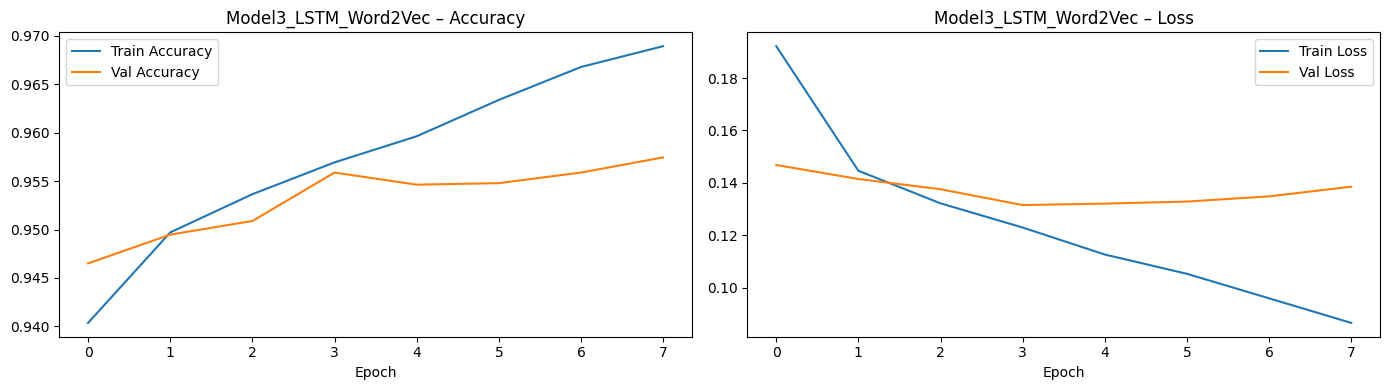


Model3_LSTM_Word2Vec | Accuracy: 95.59%
              precision    recall  f1-score   support

    Not Hate       0.96      0.99      0.98      5945
        Hate       0.80      0.50      0.61       448

    accuracy                           0.96      6393
   macro avg       0.88      0.74      0.79      6393
weighted avg       0.95      0.96      0.95      6393



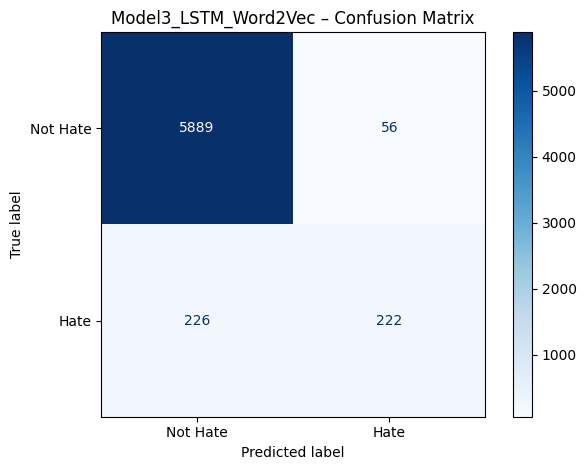

In [ ]:
plot_history(history3, 'Model3_LSTM_Word2Vec')
acc3, pred3 = evaluate_model(model3, X_val_pad, y_val, 'Model3_LSTM_Word2Vec')

## Section 9: Cross-Model Comparison


### 9.1 Validation Accuracy Bar Chart


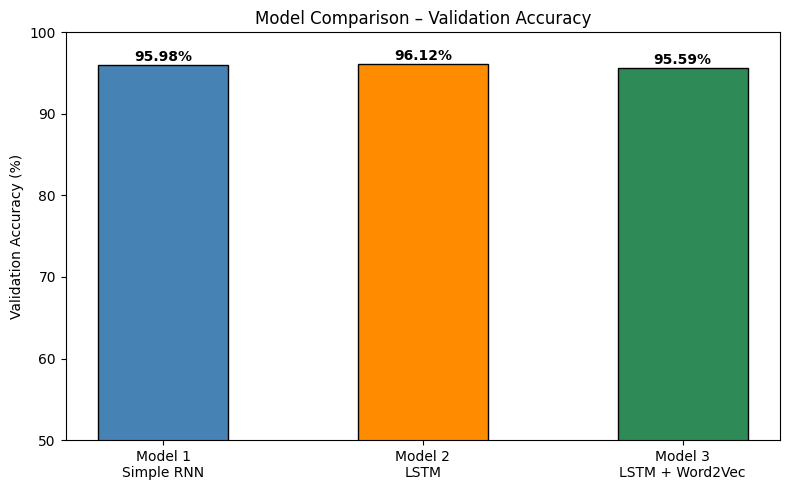

In [ ]:
# Side-by-side bar chart of validation accuracy for quick model comparison
model_names = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
accuracies  = [acc1 * 100, acc2 * 100, acc3 * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black', width=0.5)
plt.ylim(50, 100)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison – Validation Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Validation Loss Curves


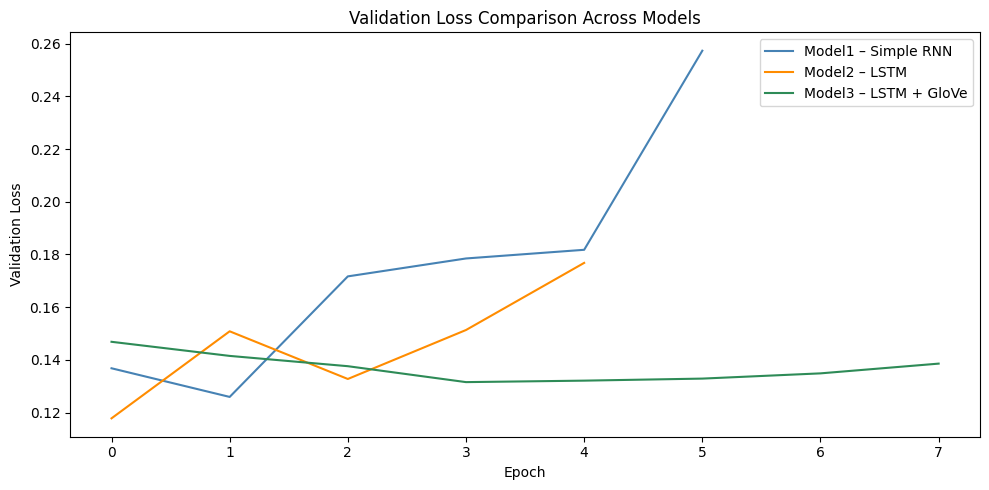

In [ ]:
# Overlay validation loss curves to compare how quickly each model converges
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_loss'], label='Model1 – Simple RNN',  color='steelblue')
plt.plot(history2.history['val_loss'], label='Model2 – LSTM',         color='darkorange')
plt.plot(history3.history['val_loss'], label='Model3 – LSTM + GloVe', color='seagreen')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison Across Models')
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 Results Summary Table


In [ ]:
# Consolidated results table: architecture, embedding type, and validation accuracy
summary = pd.DataFrame({
    'Model'        : ['Model1_SimpleRNN', 'Model2_LSTM', 'Model3_LSTM_GloVe'],
    'Embedding'    : ['Trainable', 'Trainable', 'Pre-trained GloVe (frozen)'],
    'Val_Accuracy' : [f'{acc1*100:.2f}%', f'{acc2*100:.2f}%', f'{acc3*100:.2f}%'],
})
print(summary.to_string(index=False))

            Model                  Embedding Val_Accuracy
 Model1_SimpleRNN                  Trainable       95.98%
      Model2_LSTM                  Trainable       96.12%
Model3_LSTM_GloVe Pre-trained GloVe (frozen)       95.59%


## Section 10: Error Investigation


### 10.1 Locate Misclassified Examples


In [ ]:
# Reconstruct the validation subset so predictions can be matched to source tweets
_, val_idx = train_test_split(np.arange(len(train_df)), test_size=0.2,
                              random_state=42, stratify=train_df['label'].values)

val_df = train_df.iloc[val_idx].copy().reset_index(drop=True)
val_df['predicted'] = pred3
val_df['correct']   = (val_df['label'] == val_df['predicted'])

mistakes = val_df[~val_df['correct']].reset_index(drop=True)
print(f"Misclassified: {len(mistakes)} / {len(val_df)} ({len(mistakes)/len(val_df)*100:.1f}%)")

Misclassified: 282 / 6393 (4.4%)


### 10.2 Review Individual Mistakes


In [ ]:
# Print up to 3 misclassified tweets with their true and predicted labels
for i in range(min(3, len(mistakes))):
    row = mistakes.iloc[i]
    print(f"\nExample {i+1}")
    print(f"  Tweet     : {row['tweet']}")
    print(f"  True Label: {int(row['label'])} ({'Hate' if row['label']==1 else 'Not Hate'})")
    print(f"  Predicted : {int(row['predicted'])} ({'Hate' if row['predicted']==1 else 'Not Hate'})")


Example 1
  Tweet     : beware the "snowball effect" blackman! pa 2   
  True Label: 1 (Hate)
  Predicted : 0 (Not Hate)

Example 2
  Tweet     : the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 
  True Label: 1 (Hate)
  Predicted : 0 (Not Hate)

Example 3
  Tweet     :  porn vids web free sex 
  True Label: 1 (Hate)
  Predicted : 0 (Not Hate)


### 10.3 False Positive & False Negative Counts


In [ ]:
# Quantify false alarms (FP) and missed detections (FN) separately
fp = len(val_df[(val_df['label']==0) & (val_df['predicted']==1)])
fn = len(val_df[(val_df['label']==1) & (val_df['predicted']==0)])
print(f"False Positives (predicted Hate, actually Not Hate): {fp}")
print(f"False Negatives (predicted Not Hate, actually Hate): {fn}")

False Positives (predicted Hate, actually Not Hate): 56
False Negatives (predicted Not Hate, actually Hate): 226


### 10.4 Root Cause Analysis


In [ ]:
print("\nLikely contributing factors:")
print("  1. Sarcasm or irony making the true intent unclear")
print("  2. Very short tweets that lose meaning after stopword removal")
print("  3. Out-of-vocabulary slang not present in the Word2Vec corpus")
print("  4. Severe label skew (~93% non-hate) pushes the model toward the majority class")


Possible reasons:
  1. Sarcastic or ambiguous language that flips sentiment
  2. Short tweets with too little context after cleaning
  3. Rare words not covered by the GloVe vocabulary
  4. Class imbalance (~93% non-hate) biases predictions toward majority class


### 10.5 Recommendations for Future Work


In [ ]:
print("\nPotential next steps:")
print("  • Apply class-weighted loss to up-weight minority-class errors")
print("  • Replace unidirectional LSTM with a Bidirectional wrapper")
print("  • Experiment with domain-adapted embeddings (e.g. glove-twitter-100)")
print("  • Unfreeze and fine-tune the embedding layer on social-media corpora")


Suggested improvements:
  • Add class weights to penalise errors on the minority class
  • Use Bidirectional LSTM for richer contextual representation
  • Try Twitter-specific embeddings (glove-twitter-100)
  • Fine-tune the embedding layer on domain-specific data
